In [54]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
%matplotlib inline 
sns.set(style="ticks")

## Загрузка и первичный анализ данных

In [55]:
data = pd.read_csv('pizza_sales.csv', sep=",")

In [56]:
# размер набора данных
data.shape

(48620, 12)

In [57]:
# типы колонок
data.dtypes

pizza_id             float64
order_id             float64
pizza_name_id         object
quantity             float64
order_date            object
order_time            object
unit_price           float64
total_price          float64
pizza_size            object
pizza_category        object
pizza_ingredients     object
pizza_name            object
dtype: object

In [58]:
# проверим есть ли пропущенные значения
data.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

In [59]:
# Первые 5 строк датасета
data.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1.0,1.0,hawaiian_m,1.0,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2.0,2.0,classic_dlx_m,1.0,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3.0,2.0,five_cheese_l,1.0,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4.0,2.0,ital_supr_l,1.0,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5.0,2.0,mexicana_m,1.0,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [60]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 48620


## Кодирование категориальных признаков

In [61]:
data.drop(['pizza_id', 'order_id', "pizza_name_id"], axis=1, inplace=True)

In [62]:
data['order_date'] = data['order_date'].str.replace('-', '/')
data['order_date'] = pd.to_datetime(data['order_date'], format='%d/%m/%Y')
data['year'] = data['order_date'].dt.year
data['month'] = data['order_date'].dt.month
data['day'] = data['order_date'].dt.day
data.drop('order_date', axis=1, inplace=True)

In [63]:
data['order_time'] = pd.to_datetime(data['order_time'], format='%H:%M:%S')
data['order_hour'] = data['order_time'].dt.hour
data.drop('order_time', axis=1, inplace=True)

In [64]:
size_mapping = {'S': 0, 'M': 1, 'L': 2, 'XL': 3, 'XXL': 4}
category_mapping = {'Classic': 0, 'Veggie': 1, 'Supreme': 2, 'Chicken': 3}

In [65]:
data['pizza_size_encoded'] = data['pizza_size'].map(size_mapping)
data['pizza_category_encoded'] = data['pizza_category'].map(category_mapping)
data.drop(['pizza_size', 'pizza_category'], axis=1, inplace=True)

In [66]:
data['pizza_name_encoded'] = pd.factorize(data['pizza_name'])[0]
data.drop(['pizza_ingredients', 'pizza_name'], axis=1, inplace=True)

In [67]:
data.head()

,quantity,unit_price,total_price,year,month,day,order_hour,pizza_size_encoded,pizza_category_encoded,pizza_name_encoded
0,1.0,13.25,13.25,2015,1,1,11,1,0,0
1,1.0,16.00,16.00,2015,1,1,11,1,0,1
2,1.0,18.50,18.50,2015,1,1,11,2,1,2
3,1.0,20.75,20.75,2015,1,1,11,2,2,3
4,1.0,16.00,16.00,2015,1,1,11,1,1,4


## Разделение выборки на тестовую и обучающую

In [68]:
from sklearn.model_selection import train_test_split

In [69]:
X = data.drop('total_price', axis=1)  # Признаки (все кроме целевой)
y = data['total_price']                # Целевая переменная

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% на тест
    random_state=42,    # для воспроизводимости
    shuffle=True        # перемешиваем данные перед разделением
)

## Обучение ансамблевых моделей

### 1) Бэггинг

In [70]:
from sklearn.ensemble import BaggingRegressor, BaggingClassifier
from sklearn.tree import plot_tree
import ehrapy as ep

In [112]:
# Создаем бэггинг с 5 деревьями
bc1 = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=10),
    n_estimators=5,
    oob_score=True,  # используем Out-of-Bag оценку
    random_state=10,
    bootstrap=True   # бутстреп выборка (по умолчанию True)
)

In [113]:
bc1.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...ndom_state=10)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",5
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",True
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",10
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [114]:
bc1.estimators_samples_

[array([17829, 24201,  3508, ..., 19538,  7430, 33425],
       shape=(38896,), dtype=int32),
 array([24535, 18154, 17245, ..., 26356, 30830,  8473],
       shape=(38896,), dtype=int32),
 array([26009, 34811, 33411, ...,  7699,  3886, 27773],
       shape=(38896,), dtype=int32),
 array([10838, 21470, 28471, ..., 35231, 31298,  6347],
       shape=(38896,), dtype=int32),
 array([ 4752,  1806, 24183, ..., 30829, 37245, 17811],
       shape=(38896,), dtype=int32)]

In [115]:
# Создаем двоичную матрицу: 1 - элемент попал в обучающую выборку
bin_array = np.zeros((bc1.n_estimators, X_train.shape[0]))
for i in range(5):
    for j in bc1.estimators_samples_[i]:
        bin_array[i][j] = 1
bin_array

array([[0., 0., 0., ..., 1., 0., 1.],
       [1., 0., 0., ..., 1., 1., 0.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 0., 1., 1.],
       [0., 1., 0., ..., 1., 0., 1.]], shape=(5, 38896))

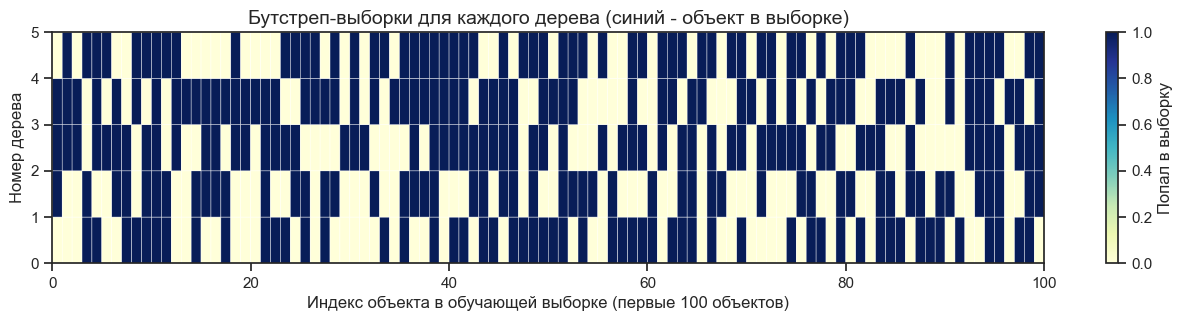

In [116]:
# Визуализируем (синим показаны данные, попавшие в обучающую выборку)
n_samples_to_show = 100

bin_array_small = bin_array[:, :n_samples_to_show]

fig, ax = plt.subplots(figsize=(16, 3))
im = ax.pcolor(bin_array_small, cmap='YlGnBu', edgecolors='white', linewidth=0.3)
ax.set_xlabel('Индекс объекта в обучающей выборке (первые {} объектов)'.format(n_samples_to_show), fontsize=12)
ax.set_ylabel('Номер дерева', fontsize=12)
ax.set_title('Бутстреп-выборки для каждого дерева (синий - объект в выборке)', fontsize=14)
plt.colorbar(im, ax=ax, label='Попал в выборку')

In [119]:
# Оценим Out-of-bag error, теоретическое значение 37%
for i in range(bc1.n_estimators):
    cur_data = bin_array[i]
    len_cur_data = len(cur_data)
    sum_cur_data = sum(cur_data)
    oob_percent = (len_cur_data - sum_cur_data) / len_cur_data * 100
    in_bag_percent = 100 - oob_percent
    print(f"Дерево №{i+1}: "
          f"В выборке: {int(sum_cur_data):.0f} объектов ({in_bag_percent:.1f}%), "
          f"OOB: {len_cur_data - int(sum_cur_data)} объектов ({oob_percent:.1f}%)")

Дерево №1: В выборке: 24621 объектов (63.3%), OOB: 14275 объектов (36.7%)
Дерево №2: В выборке: 24526 объектов (63.1%), OOB: 14370 объектов (36.9%)
Дерево №3: В выборке: 24576 объектов (63.2%), OOB: 14320 объектов (36.8%)
Дерево №4: В выборке: 24487 объектов (63.0%), OOB: 14409 объектов (37.0%)
Дерево №5: В выборке: 24593 объектов (63.2%), OOB: 14303 объектов (36.8%)


In [118]:
# Out-of-bag error, возвращаемый классификатором
# Для классификации используется метрика accuracy
bc1.oob_score_, 1-bc1.oob_score_

(-0.5437359828464474, 1.5437359828464474)

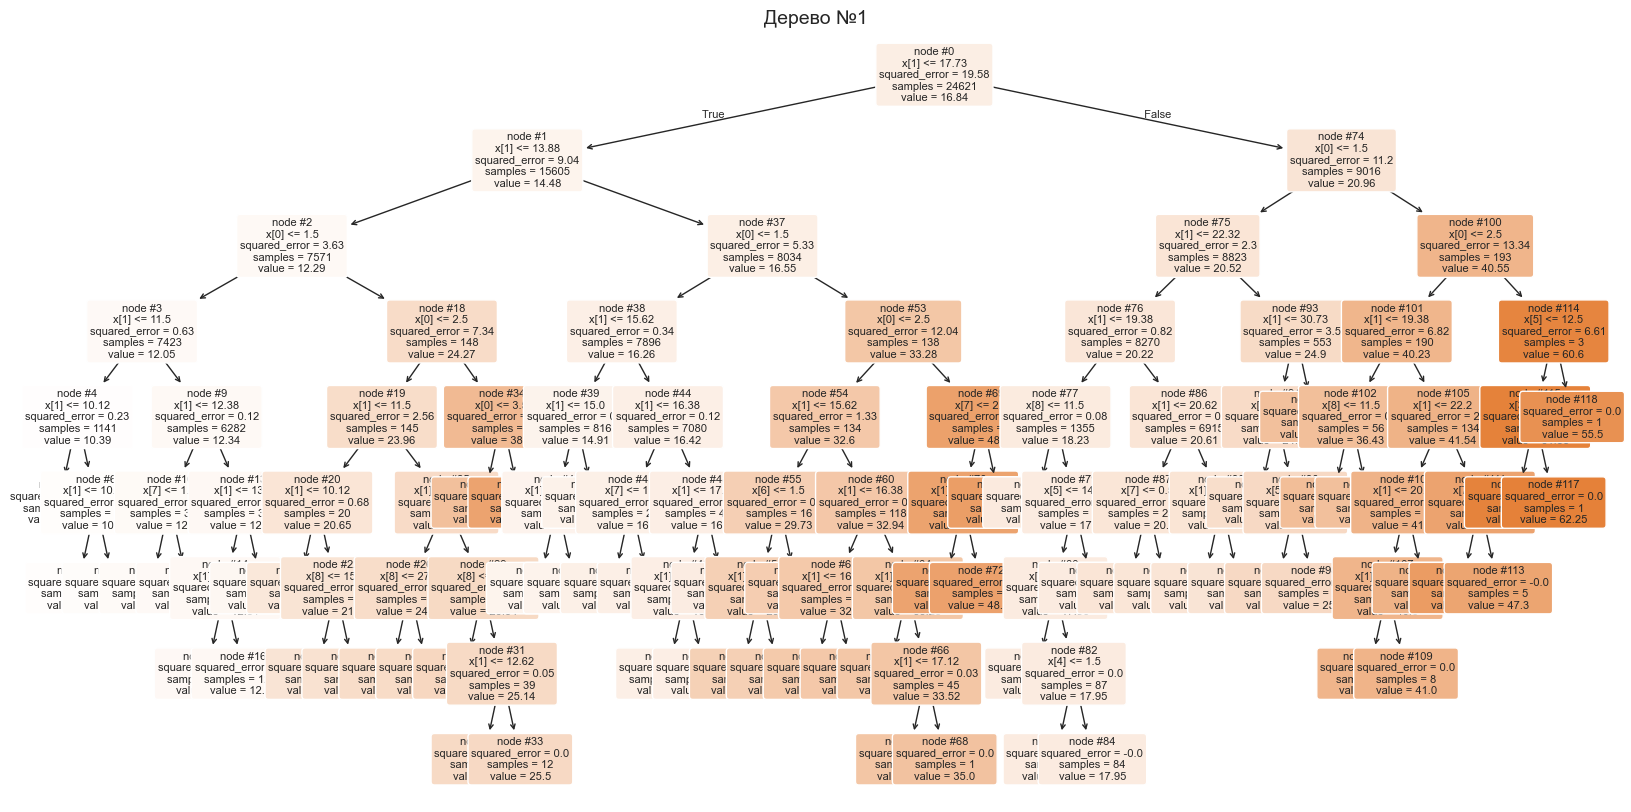

In [78]:
# Пример с дополнительными настройками
plt.figure(figsize=(20, 10))
plot_tree(
    bc1.estimators_[0],
    filled=True,
    rounded=True,
    fontsize=8,
    precision=2,
    node_ids=True
)
plt.title('Дерево №1', fontsize=14)
plt.show()

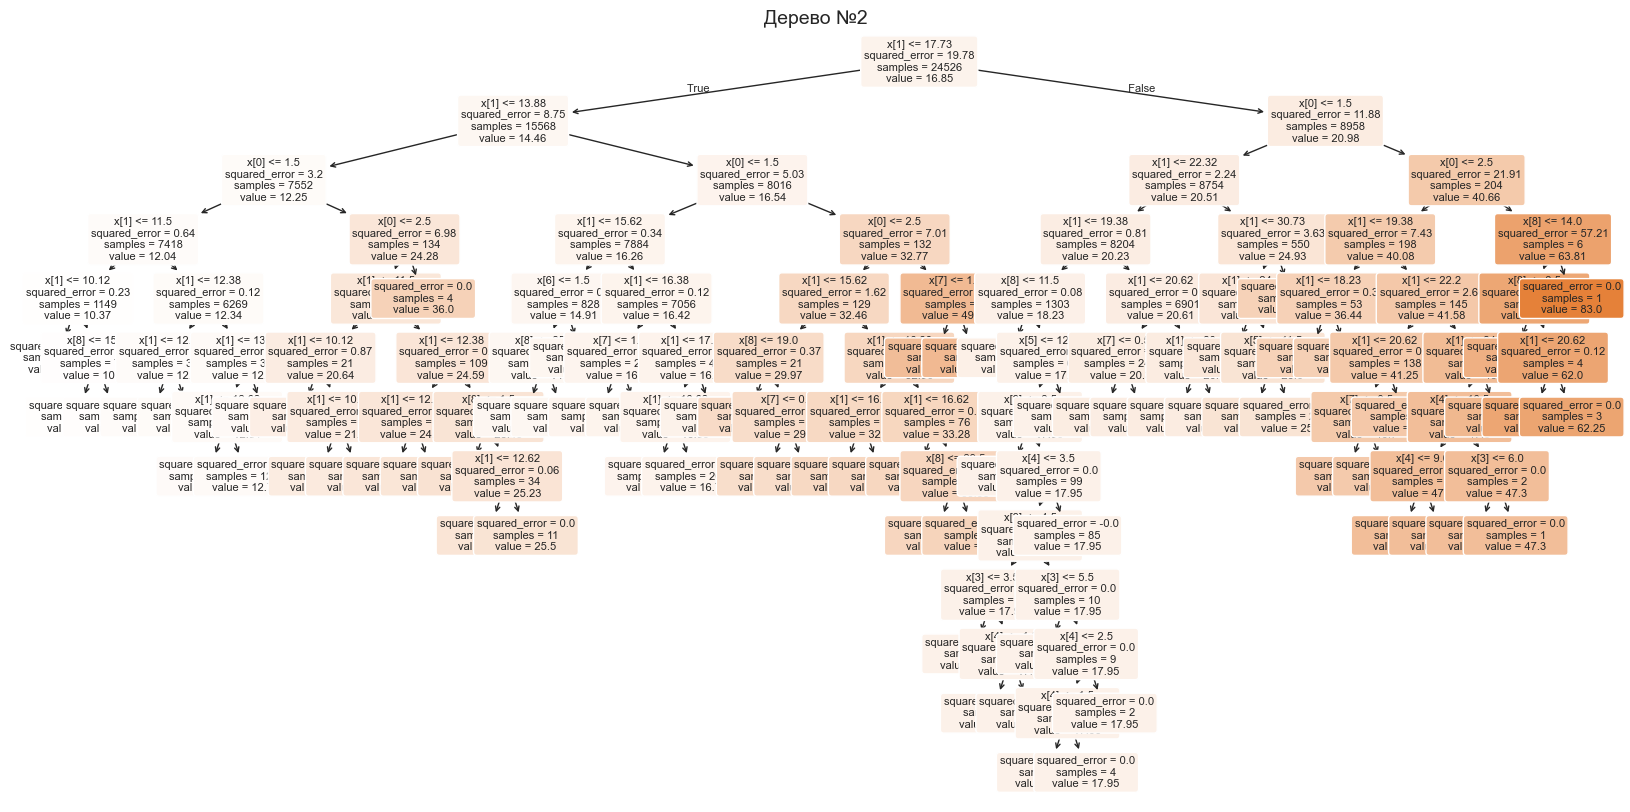

In [120]:
plt.figure(figsize=(20, 10))
plot_tree(
    bc1.estimators_[1],
    filled=True,
    rounded=True,
    fontsize=8,
    precision=2
)
plt.title('Дерево №2', fontsize=14)
plt.show()

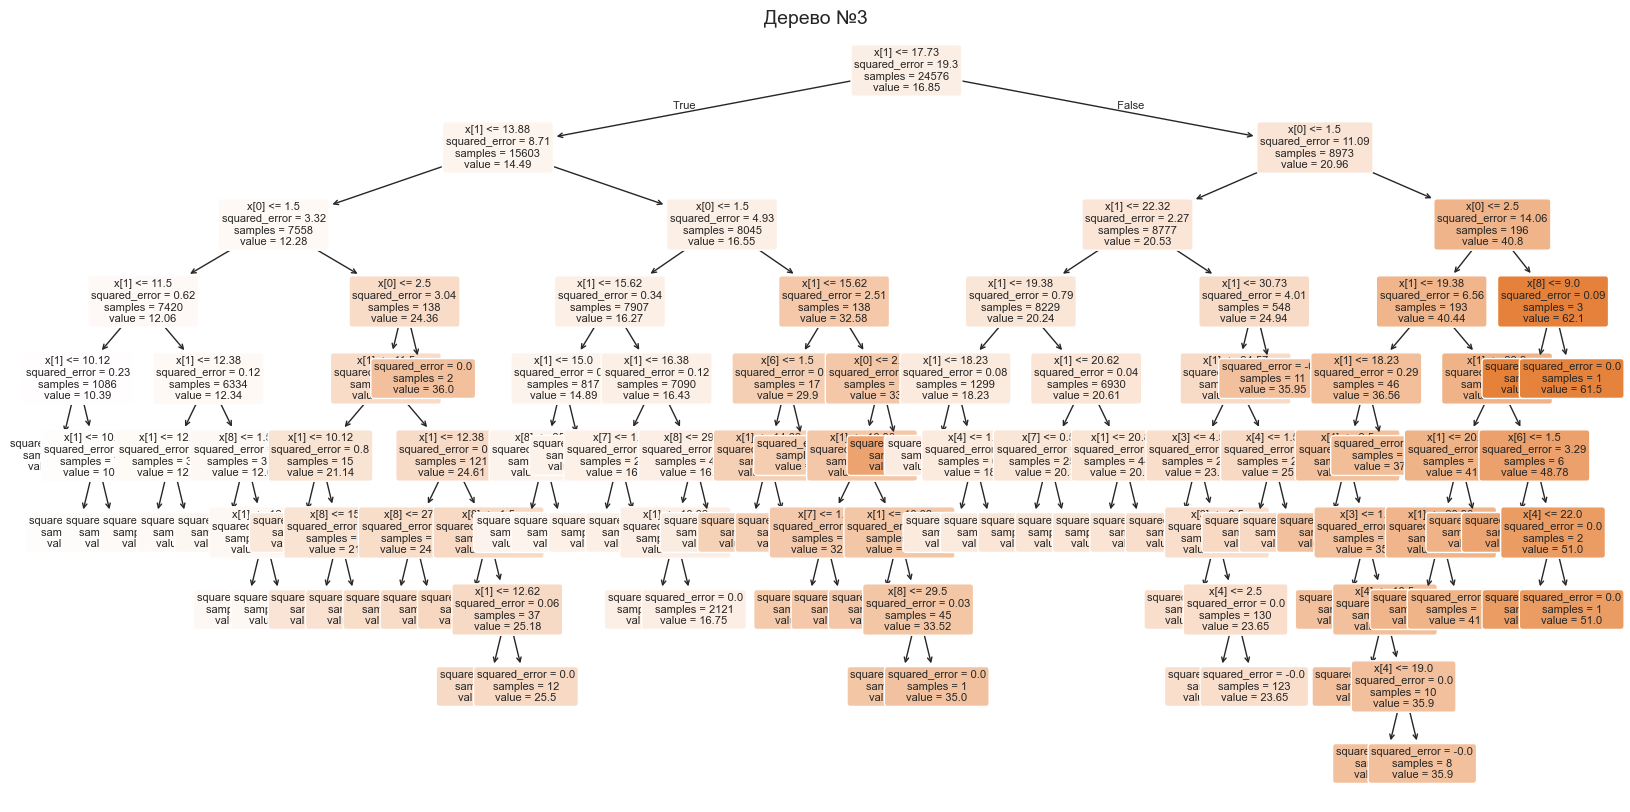

In [121]:
plt.figure(figsize=(20, 10))
plot_tree(
    bc1.estimators_[2],
    filled=True,
    rounded=True,
    fontsize=8,
    precision=2
)
plt.title('Дерево №3', fontsize=14)
plt.show()

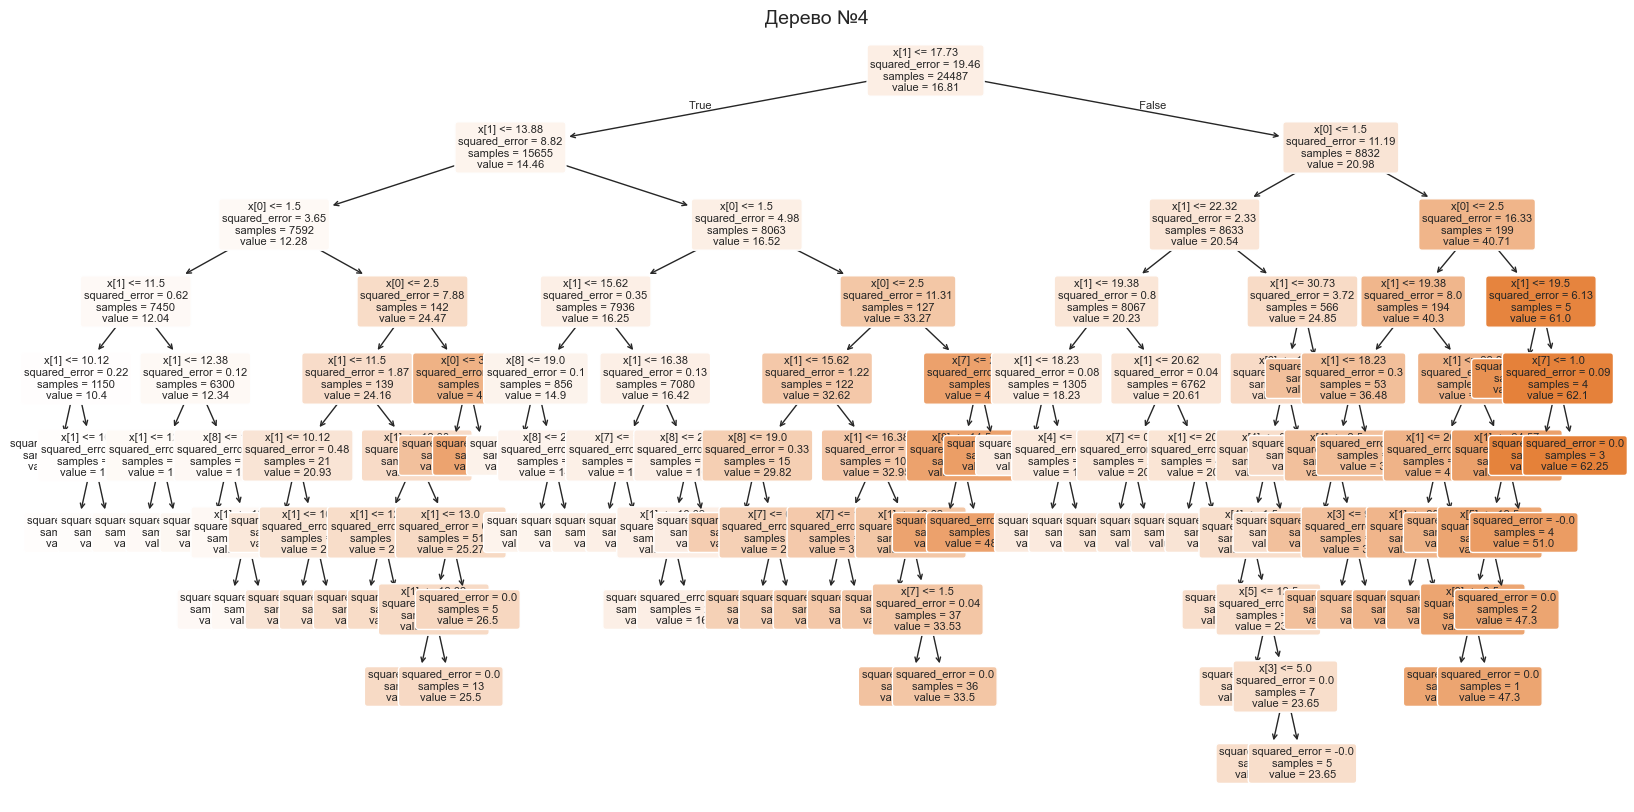

In [122]:
plt.figure(figsize=(20, 10))
plot_tree(
    bc1.estimators_[3],
    filled=True,
    rounded=True,
    fontsize=8,
    precision=2
)
plt.title('Дерево №4', fontsize=14)
plt.show()

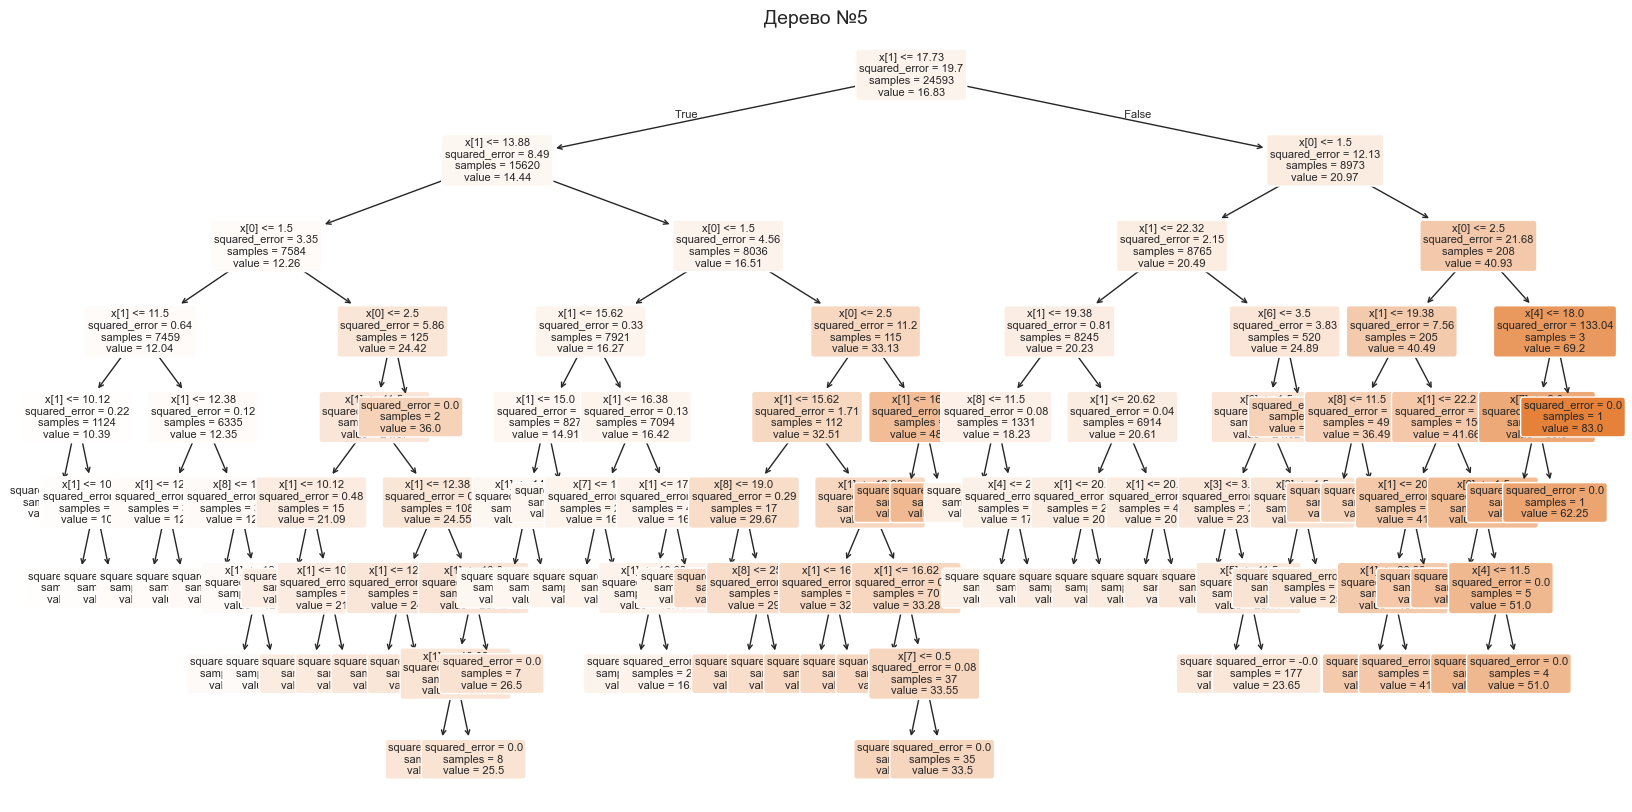

In [123]:
plt.figure(figsize=(20, 10))
plot_tree(
    bc1.estimators_[4],
    filled=True,
    rounded=True,
    fontsize=8,
    precision=2
)
plt.title('Дерево №5', fontsize=14)
plt.show()

### 2) AdaBoost

In [83]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [84]:
X_ada = X_train[['order_hour', 'pizza_size_encoded']].values
y_ada = y_train.values

# Обучим классификатор на 5 деревьях (для регрессии)
ab1 = AdaBoostRegressor(n_estimators=5, random_state=10)
ab1.fit(X_ada, y_ada)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",5
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",10


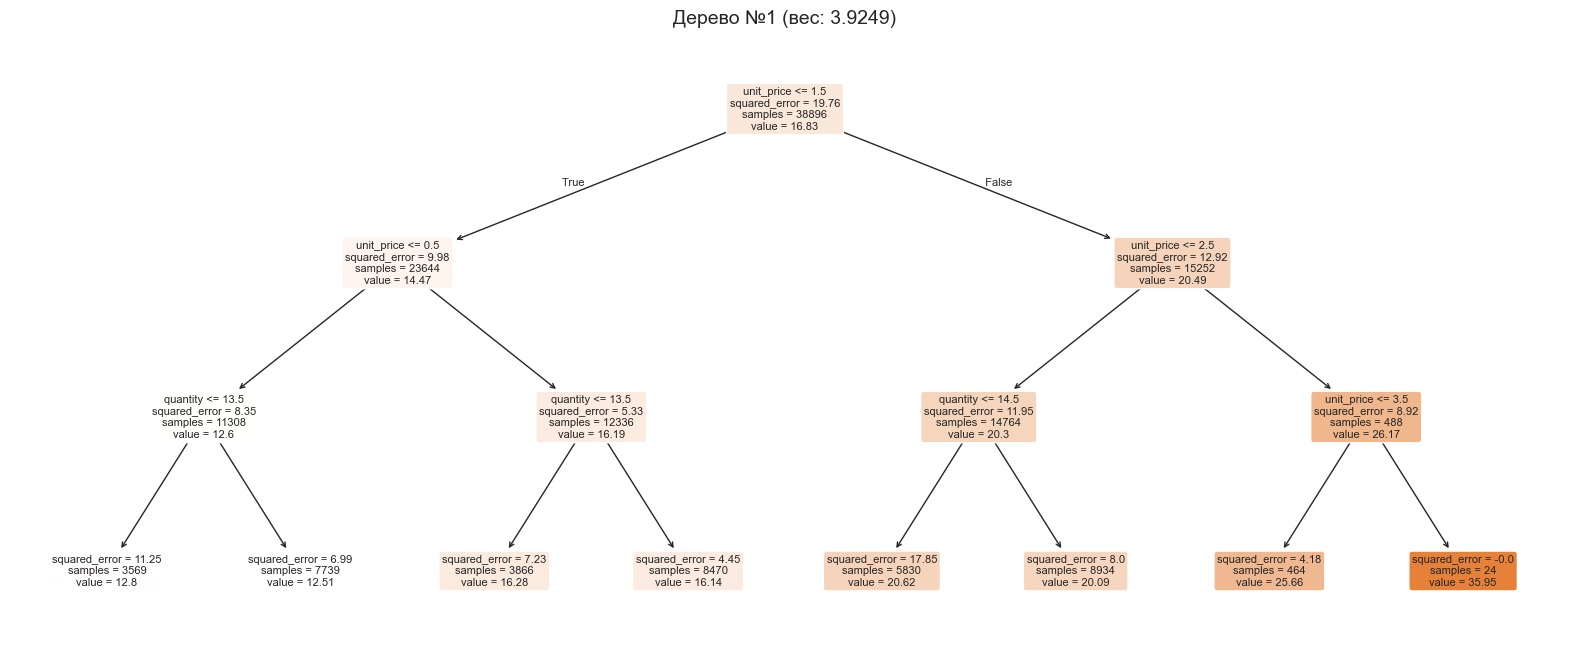

In [85]:
plt.figure(figsize=(20, 8))
plot_tree(
    ab1.estimators_[0],
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    fontsize=8,
    precision=2
)

plt.title(f'Дерево №{1} (вес: {ab1.estimator_weights_[0]:.4f})', fontsize=14)
plt.show()

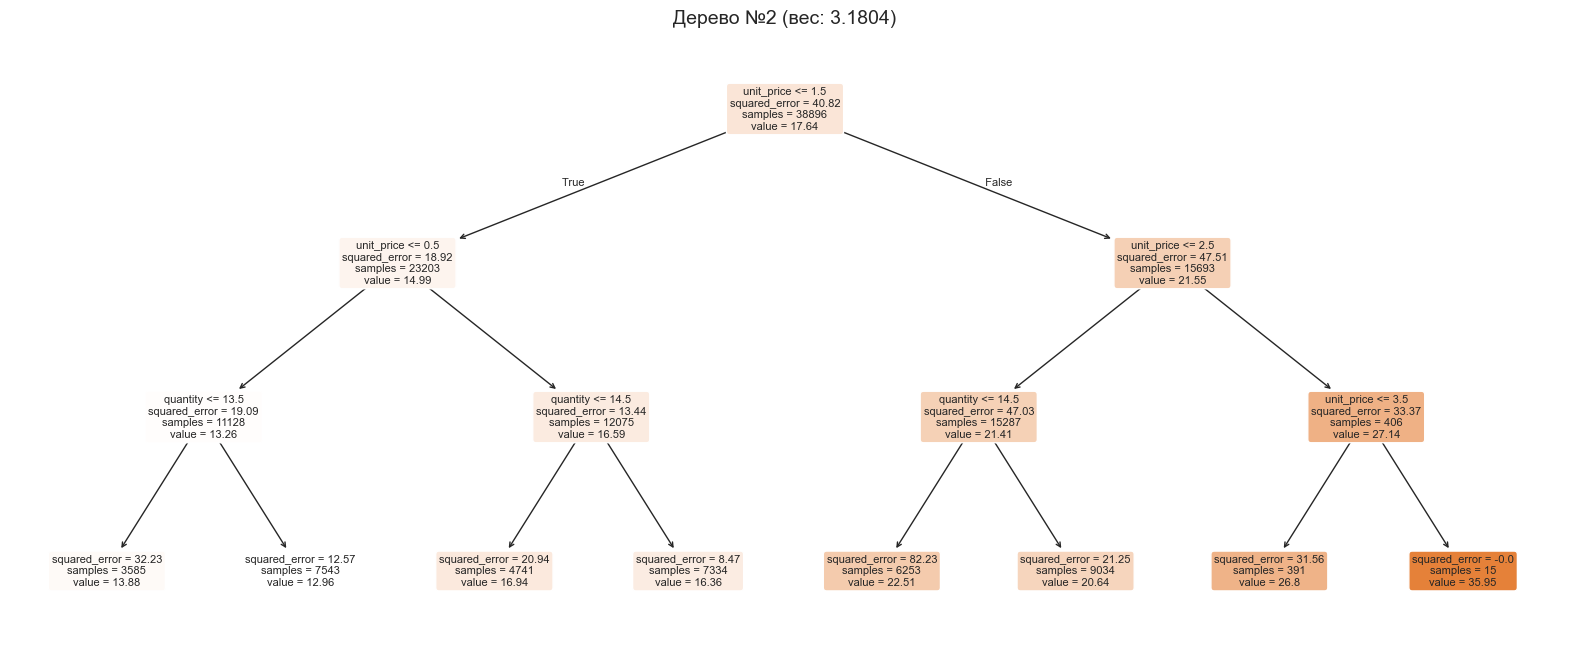

In [86]:
plt.figure(figsize=(20, 8))
plot_tree(
    ab1.estimators_[1],
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    fontsize=8,
    precision=2
)

plt.title(f'Дерево №{2} (вес: {ab1.estimator_weights_[1]:.4f})', fontsize=14)
plt.show()

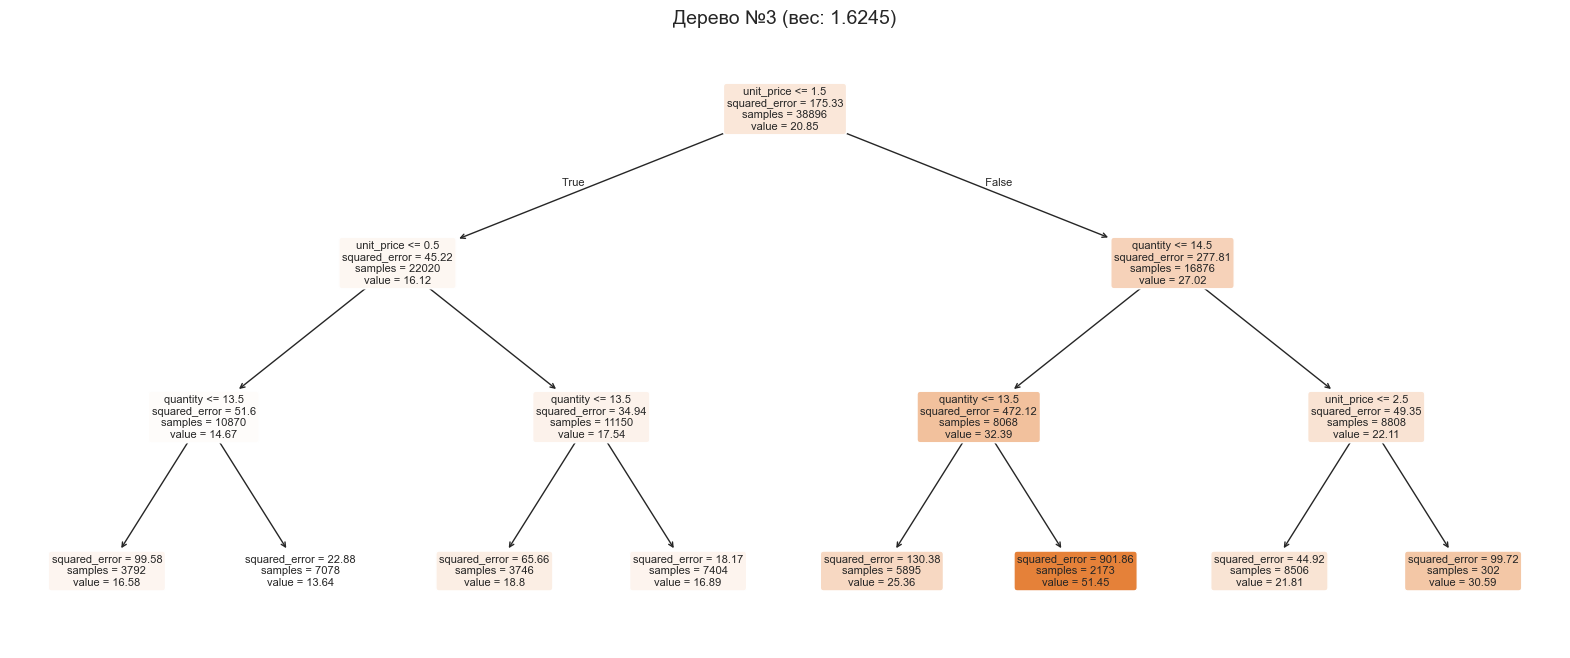

In [87]:
plt.figure(figsize=(20, 8))
plot_tree(
    ab1.estimators_[2],
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    fontsize=8,
    precision=2
)

plt.title(f'Дерево №{3} (вес: {ab1.estimator_weights_[2]:.4f})', fontsize=14)
plt.show()

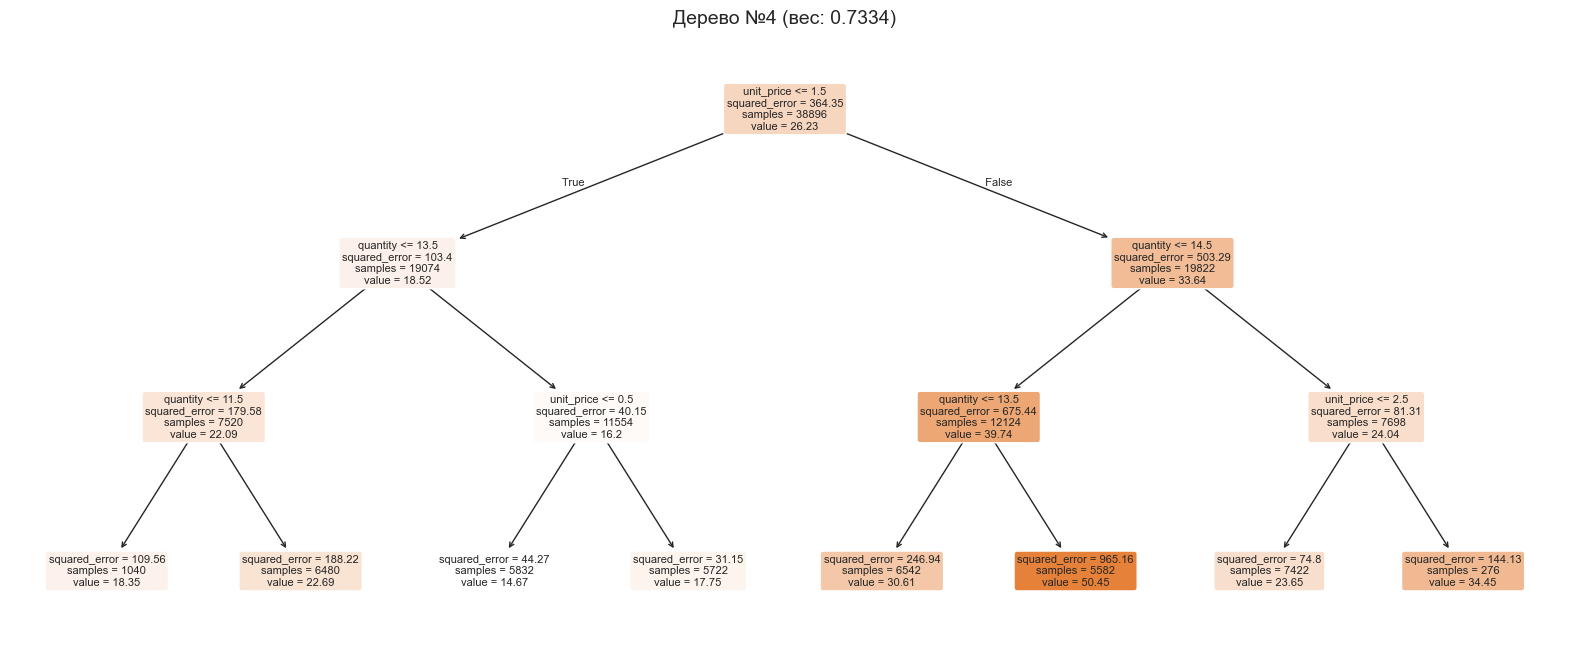

In [88]:
plt.figure(figsize=(20, 8))
plot_tree(
    ab1.estimators_[3],
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    fontsize=8,
    precision=2
)

plt.title(f'Дерево №{4} (вес: {ab1.estimator_weights_[3]:.4f})', fontsize=14)
plt.show()

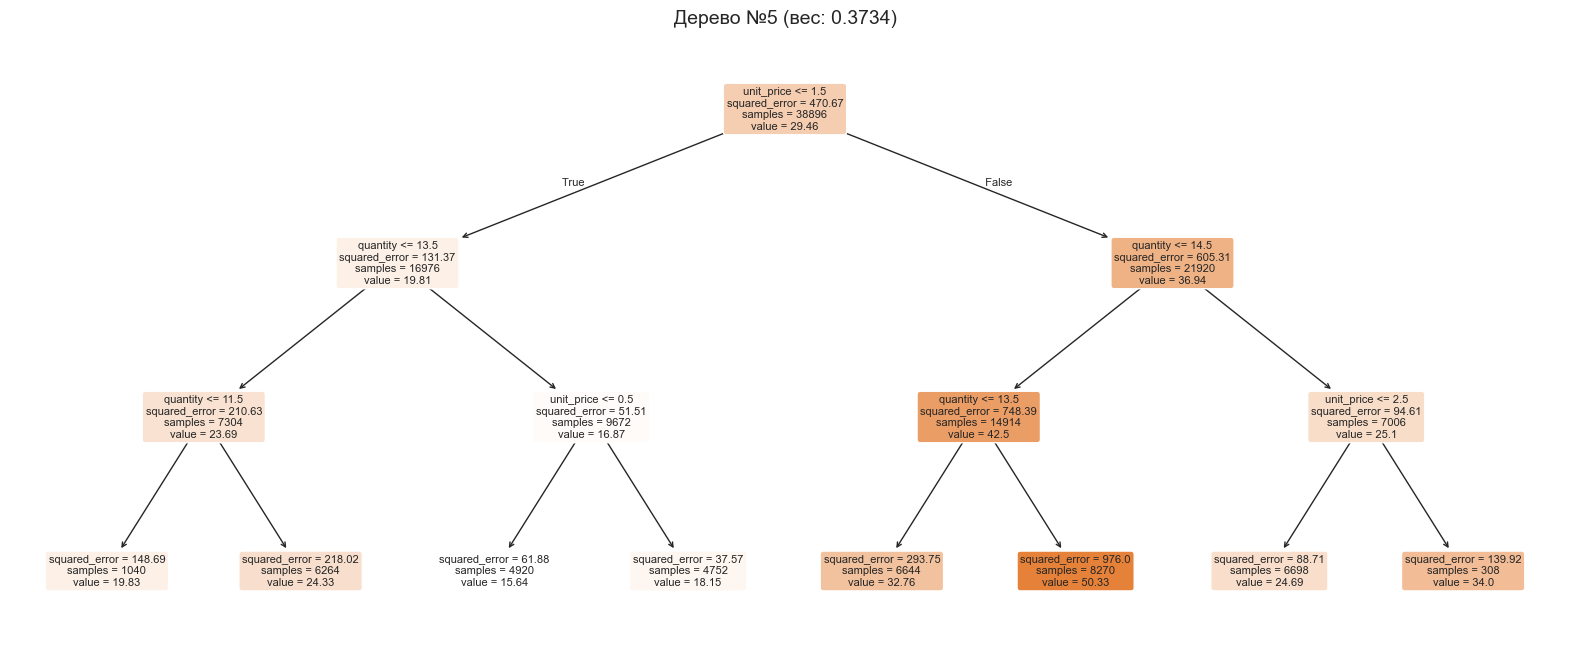

In [89]:
plt.figure(figsize=(20, 8))
plot_tree(
    ab1.estimators_[4],
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    fontsize=8,
    precision=2
)

plt.title(f'Дерево №{5} (вес: {ab1.estimator_weights_[4]:.4f})', fontsize=14)
plt.show()

In [90]:
ab1.estimator_weights_

array([3.92492837, 3.18042312, 1.6245381 , 0.73340171, 0.37340175])

In [91]:
df1 = ab1.decision_function(X_ada) if hasattr(ab1, 'decision_function') else ab1.predict(X_ada)
df1.shape

(38896,)

In [92]:
df1[:10]

array([12.95753679, 13.88456067, 16.93508753, 20.64245628, 12.95753679,
       12.95753679, 16.3612967 , 16.3612967 , 12.95753679, 20.64245628])

### 3) Градиентный бустинг

In [93]:
from sklearn.ensemble import GradientBoostingRegressor

In [94]:
X_ada = X_train[['order_hour', 'pizza_size_encoded']].values
y_ada = y_train.values

In [95]:
# Обучим градиентный бустинг на 5 деревьях
gb1 = GradientBoostingRegressor(n_estimators=5, random_state=10)
gb1.fit(X_ada, y_ada)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",5
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft ch

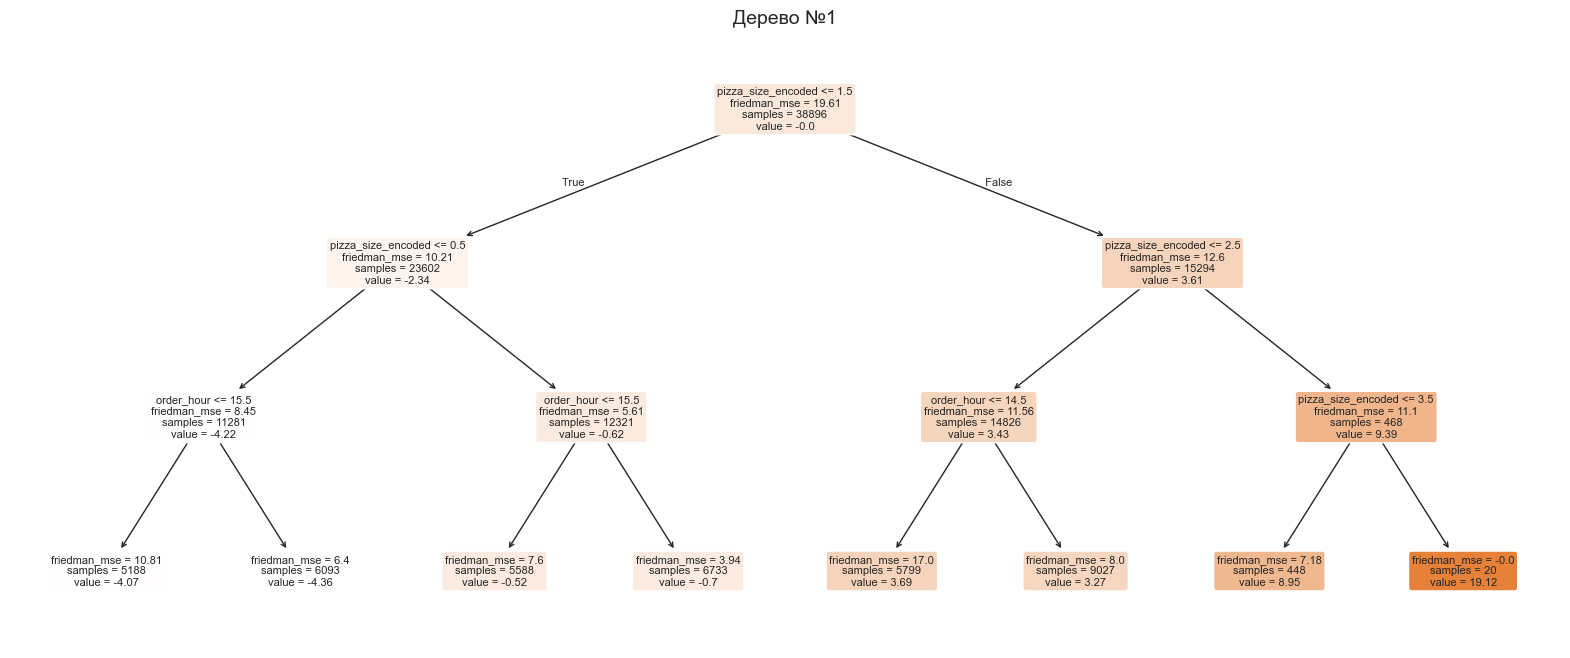

In [96]:
plt.figure(figsize=(20, 8))
plot_tree(gb1.estimators_[0][0], feature_names=['order_hour', 'pizza_size_encoded'], 
        filled=True, rounded=True, fontsize=8, precision=2)
plt.title(f'Дерево №1', fontsize=14)
plt.show()

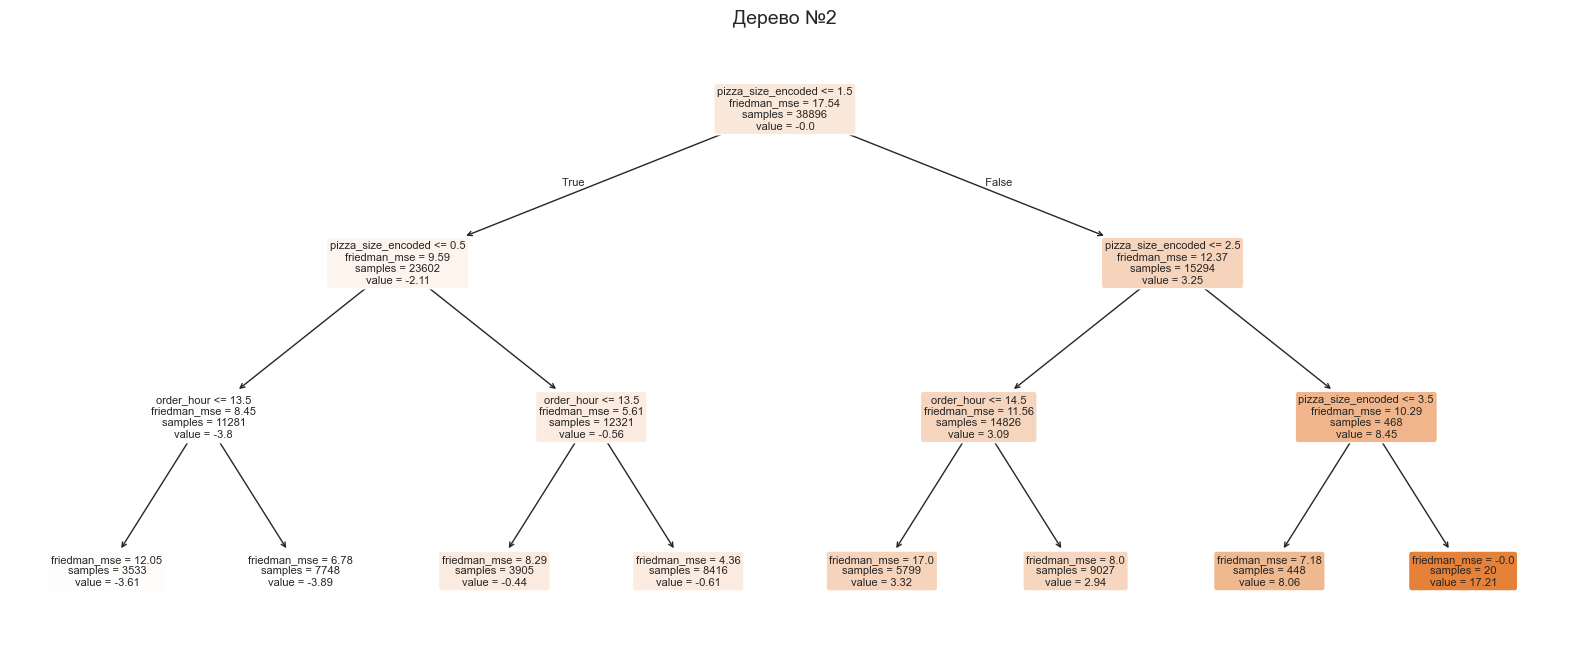

In [97]:
plt.figure(figsize=(20, 8))
plot_tree(gb1.estimators_[1][0], feature_names=['order_hour', 'pizza_size_encoded'], 
        filled=True, rounded=True, fontsize=8, precision=2)
plt.title(f'Дерево №2', fontsize=14)
plt.show()

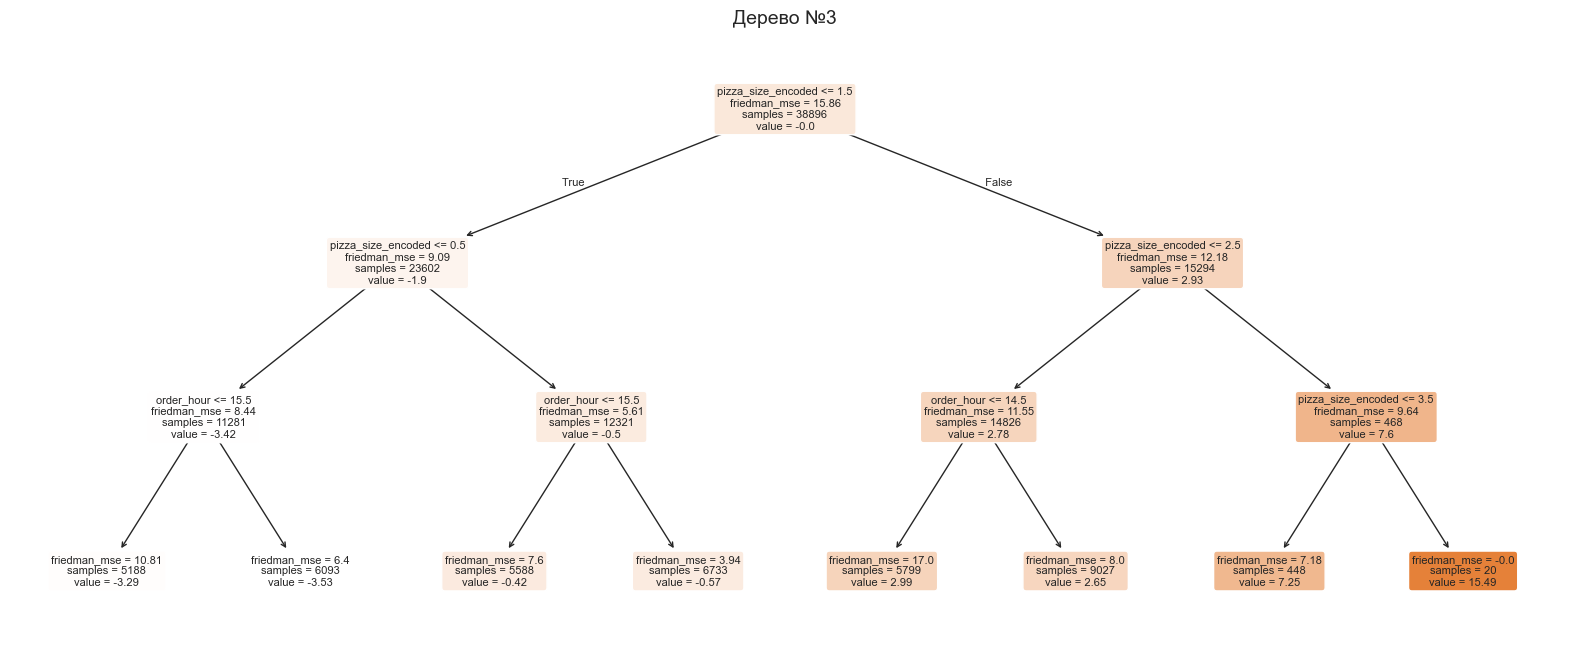

In [98]:
plt.figure(figsize=(20, 8))
plot_tree(gb1.estimators_[2][0], feature_names=['order_hour', 'pizza_size_encoded'], 
        filled=True, rounded=True, fontsize=8, precision=2)
plt.title(f'Дерево №3', fontsize=14)
plt.show()

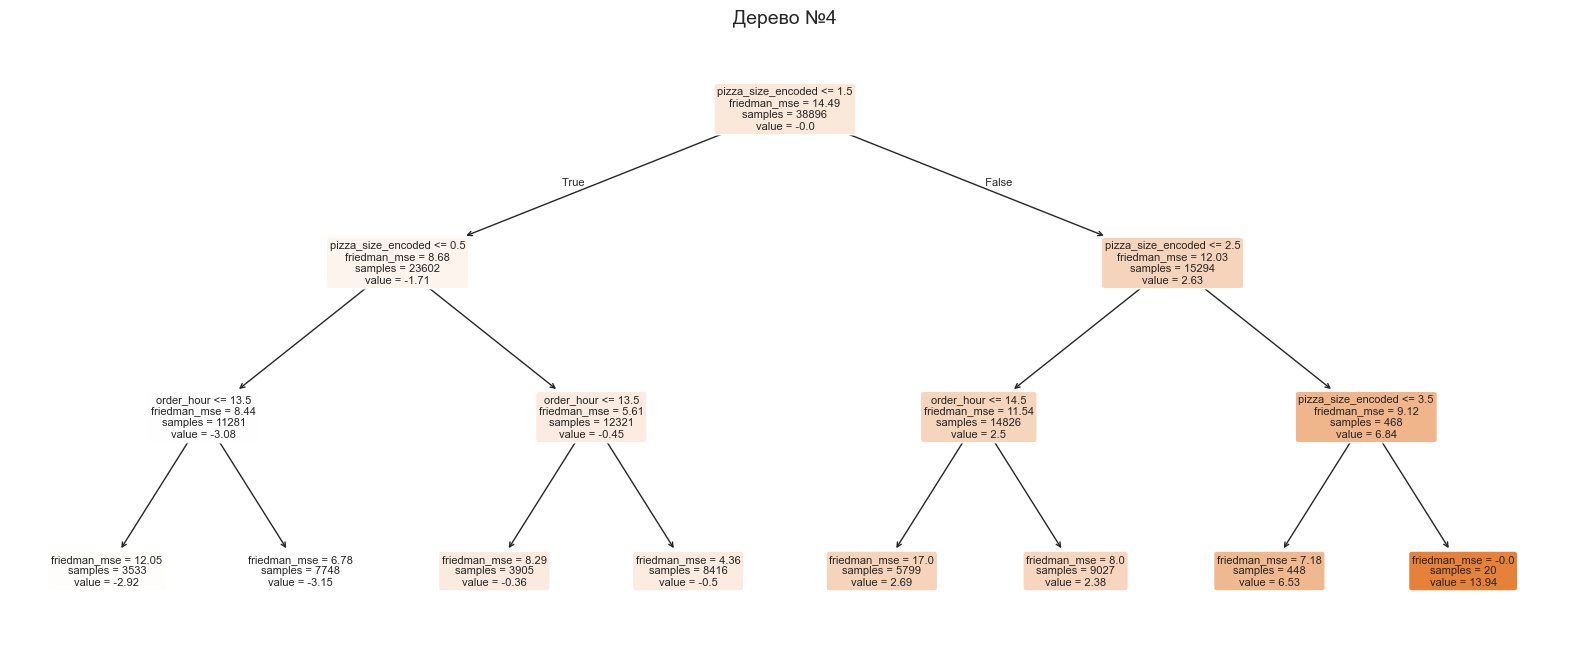

In [99]:
plt.figure(figsize=(20, 8))
plot_tree(gb1.estimators_[3][0], feature_names=['order_hour', 'pizza_size_encoded'], 
        filled=True, rounded=True, fontsize=8, precision=2)
plt.title(f'Дерево №4', fontsize=14)
plt.show()

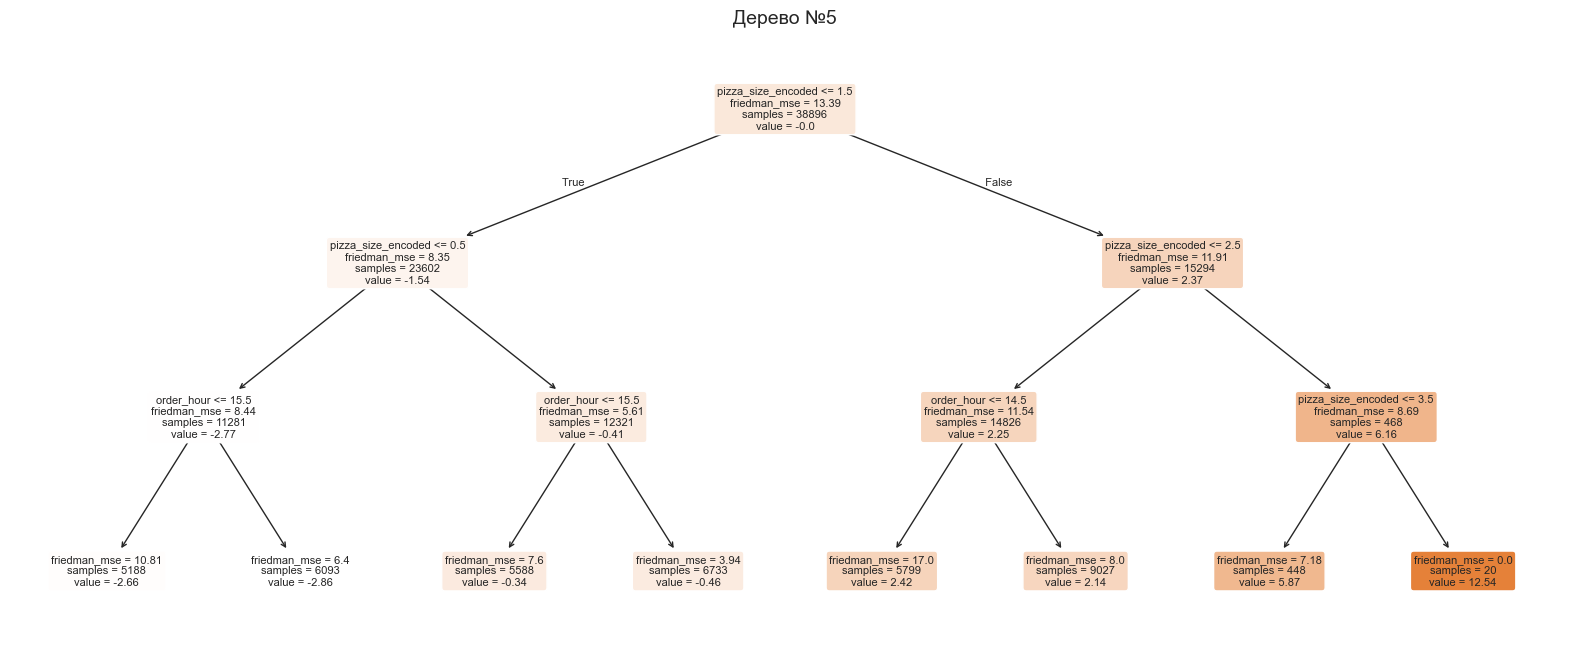

In [100]:
plt.figure(figsize=(20, 8))
plot_tree(gb1.estimators_[4][0], feature_names=['order_hour', 'pizza_size_encoded'], 
        filled=True, rounded=True, fontsize=8, precision=2)
plt.title(f'Дерево №5', fontsize=14)
plt.show()

In [101]:
gb1.estimators_.shape

(5, 1)

In [102]:
gb1.train_score_

array([17.53508659, 15.85523262, 14.49451127, 13.39230993, 12.49949827])

## Оценка качества моделей

In [103]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import AdaBoostRegressor

In [104]:
# Список моделей для сравнения
models = {
    'Decision Tree (1 дерево)': DecisionTreeRegressor(random_state=10, max_depth=5),
    'Bagging (5 деревьев)': BaggingRegressor(estimator=DecisionTreeRegressor(random_state=10), n_estimators=5, random_state=10),
    'AdaBoost (5 деревьев)': AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3, random_state=10), n_estimators=5, random_state=10),
    'Gradient Boosting (5 деревьев)': GradientBoostingRegressor(n_estimators=5, random_state=10, max_depth=3)
}

# Оценка качества
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append({
        'Модель': name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R²': r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                        Модель     RMSE      MAE       R²
      Decision Tree (1 дерево) 0.209700 0.100315 0.997803
          Bagging (5 деревьев) 0.078069 0.001357 0.999695
         AdaBoost (5 деревьев) 0.980219 0.630226 0.951989
Gradient Boosting (5 деревьев) 2.766963 1.976159 0.617436


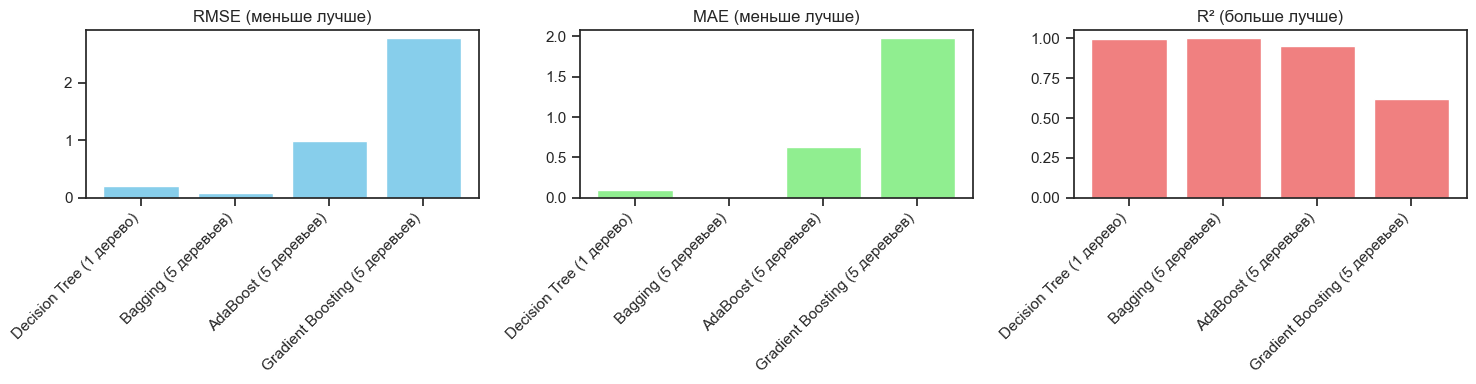

In [105]:
# Визуализация сравнения
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# RMSE
axes[0].bar(results_df['Модель'], results_df['RMSE'], color='skyblue')
axes[0].set_title('RMSE (меньше лучше)')
axes[0].set_xticklabels(results_df['Модель'], rotation=45, ha='right')

# MAE
axes[1].bar(results_df['Модель'], results_df['MAE'], color='lightgreen')
axes[1].set_title('MAE (меньше лучше)')
axes[1].set_xticklabels(results_df['Модель'], rotation=45, ha='right')

# R²
axes[2].bar(results_df['Модель'], results_df['R²'], color='lightcoral')
axes[2].set_title('R² (больше лучше)')
axes[2].set_xticklabels(results_df['Модель'], rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [106]:
# Сравнение с большим количеством деревьев (100)
models_more = {
    'Bagging (100)': BaggingRegressor(estimator=DecisionTreeRegressor(random_state=10), n_estimators=100, random_state=10, n_jobs=-1),
    'AdaBoost (100)': AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3, random_state=10), n_estimators=100, random_state=10),
    'Gradient Boosting (100)': GradientBoostingRegressor(n_estimators=100, random_state=10, max_depth=3)
}

for name, model in models_more.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name}:")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
    print(f"  R²: {r2_score(y_test, y_pred):.4f}")


Bagging (100):
  RMSE: 0.0950
  R²: 0.9995

AdaBoost (100):
  RMSE: 0.8506
  R²: 0.9638

Gradient Boosting (100):
  RMSE: 0.0701
  R²: 0.9998


In [107]:
# Вывод лучшей модели
best_model = results_df.loc[results_df['R²'].idxmax()]
print("=" * 50)
print("ЛУЧШАЯ МОДЕЛЬ (по R²):")
print("=" * 50)
print(f"Модель: {best_model['Модель']}")
print(f"RMSE: {best_model['RMSE']:.4f}")
print(f"R²: {best_model['R²']:.4f}")

ЛУЧШАЯ МОДЕЛЬ (по R²):
Модель: Bagging (5 деревьев)
RMSE: 0.0781
R²: 0.9997
